# Notebook 2: Feature Engineering

Transform the raw dataset into model-ready features.

Steps:
1. Drop leakage columns (data not available at prediction time)
2. Clean currency strings to numeric
3. Encode categoricals
4. Engineer ratio features
5. Persist processed data and the feature/state mappings

In [1]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/SBAnational.csv', low_memory=False)
print(f'Loaded {df.shape[0]:,} rows, {df.shape[1]} columns')

Loaded 899,164 rows, 27 columns


## 1. Remove leakage columns

Data leakage occurs when the model is given information that would not be available at prediction time. `ChgOffDate`, `ChgOffPrinGr`, and `BalanceGross` only exist after default has occurred and are dropped here. Identifier and high-cardinality location columns are also dropped.

In [2]:
drop_cols = [
    'LoanNr_ChkDgt',     # identifier
    'Name',              # business name
    'City',              # too granular; State is kept
    'Zip',               # too granular
    'Bank',              # high cardinality
    'BankState',         # correlated with State
    'ApprovalDate',      # ApprovalFY is kept
    'DisbursementDate',  # not available at decision time
    'ChgOffDate',        # leakage
    'ChgOffPrinGr',      # leakage
    'BalanceGross',      # leakage
]

df = df.drop(columns=drop_cols)
print(f'Remaining columns: {df.shape[1]}')
print(df.columns.tolist())

Remaining columns: 16
['State', 'NAICS', 'ApprovalFY', 'Term', 'NoEmp', 'NewExist', 'CreateJob', 'RetainedJob', 'FranchiseCode', 'UrbanRural', 'RevLineCr', 'LowDoc', 'DisbursementGross', 'MIS_Status', 'GrAppv', 'SBA_Appv']


## 2. Clean the target variable

In [3]:
print('MIS_Status value counts before cleaning:')
print(df['MIS_Status'].value_counts(dropna=False))

df = df[df['MIS_Status'].isin(['CHGOFF', 'P I F'])].copy()

df['Default'] = (df['MIS_Status'] == 'CHGOFF').astype(int)
df = df.drop(columns=['MIS_Status'])

print(f'\nRows after cleaning: {df.shape[0]:,}')
print(f'Default rate: {df["Default"].mean():.2%}')

MIS_Status value counts before cleaning:
MIS_Status
P I F     739609
CHGOFF    157558
NaN         1997
Name: count, dtype: int64

Rows after cleaning: 897,167
Default rate: 17.56%


## 3. Clean currency columns

`DisbursementGross`, `GrAppv`, and `SBA_Appv` are stored as strings like `$1,234.00` and need to be parsed to floats.

In [4]:
currency_cols = ['DisbursementGross', 'GrAppv', 'SBA_Appv']

def clean_currency(series):
    return (
        series
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.strip()
        .replace('nan', np.nan)
        .astype(float)
    )

for col in currency_cols:
    df[col] = clean_currency(df[col])
    print(f'{col}: min={df[col].min():,.0f}, max={df[col].max():,.0f}, nulls={df[col].isnull().sum()}')

# ApprovalFY contains a handful of non-numeric values (e.g. '1976A'); coerce to numeric.
df['ApprovalFY'] = pd.to_numeric(df['ApprovalFY'], errors='coerce')
print(f'ApprovalFY: min={df["ApprovalFY"].min():.0f}, max={df["ApprovalFY"].max():.0f}, nulls={df["ApprovalFY"].isnull().sum()}')

DisbursementGross: min=4,000, max=11,446,325, nulls=0
GrAppv: min=1,000, max=5,472,000, nulls=0


SBA_Appv: min=500, max=5,472,000, nulls=0


ApprovalFY: min=1966, max=2014, nulls=18


## 4. Engineer ratio features

In [5]:
# Share of the loan backed by the SBA.
df['SBA_GuaranteeRatio'] = df['SBA_Appv'] / df['GrAppv'].replace(0, np.nan)
df['SBA_GuaranteeRatio'] = df['SBA_GuaranteeRatio'].clip(0, 1)

# Fraction of the approved amount that was actually disbursed.
df['DisbursementRatio'] = df['DisbursementGross'] / df['GrAppv'].replace(0, np.nan)
df['DisbursementRatio'] = df['DisbursementRatio'].clip(0, 2)

# Loan amount per job; fall back to the full amount when no jobs are reported.
df['TotalJobs'] = df['CreateJob'] + df['RetainedJob']
df['LoanPerJob'] = df['GrAppv'] / df['TotalJobs'].replace(0, np.nan)
df['LoanPerJob'] = df['LoanPerJob'].fillna(df['GrAppv'])
df['LoanPerJob'] = df['LoanPerJob'].clip(upper=df['LoanPerJob'].quantile(0.99))

print(df[['SBA_GuaranteeRatio', 'DisbursementRatio', 'LoanPerJob']].describe())

       SBA_GuaranteeRatio  DisbursementRatio      LoanPerJob
count       897167.000000      897167.000000   897167.000000
mean             0.709698           1.113349   103227.349343
std              0.173714           0.311692   176357.677743
min              0.028140           0.010258        0.568182
25%              0.500000           1.000000    10000.000000
50%              0.750000           1.000000    33578.947368
75%              0.850000           1.000000   101000.000000
max              1.000000           2.000000  1000000.000000


## 5. Clean categorical columns

In [6]:
print('RevLineCr unique values:', df['RevLineCr'].unique())
df['RevLineCr'] = df['RevLineCr'].map({'Y': 1, 'N': 0}).fillna(0).astype(int)

print('LowDoc unique values:', df['LowDoc'].unique())
df['LowDoc'] = df['LowDoc'].map({'Y': 1, 'N': 0}).fillna(0).astype(int)

print('NewExist unique values:', df['NewExist'].unique())
df['IsNewBusiness'] = (df['NewExist'] == 2.0).astype(int)
df = df.drop(columns=['NewExist'])

df['IsFranchise'] = (df['FranchiseCode'] > 1).astype(int)
df = df.drop(columns=['FranchiseCode'])

RevLineCr unique values: <ArrowStringArray>
['N', '0', 'Y', 'T', nan, '`', ',', '1', 'C', '3', '2', 'R', '7', 'A', '5',
 '.', '4', '-', 'Q']
Length: 19, dtype: str
LowDoc unique values: <ArrowStringArray>
['Y', 'N', 'C', '1', nan, 'S', 'R', 'A', '0']
Length: 9, dtype: str
NewExist unique values: [ 2.  1.  0. nan]


## 6. Industry feature (NAICS)

Reduce NAICS to its 2-digit sector code.

In [7]:
df['NAICSCode'] = df['NAICS'].astype(str).str[:2]
df['NAICSCode'] = pd.to_numeric(df['NAICSCode'], errors='coerce').fillna(0).astype(int)
df = df.drop(columns=['NAICS'])

print('NAICS sector distribution:')
print(df['NAICSCode'].value_counts().head(10))

NAICS sector distribution:
NAICSCode
0     201667
44     84567
81     72395
54     67922
72     67511
23     66492
62     55264
42     48673
45     42408
33     38206
Name: count, dtype: int64


## 7. Encode state

Label encoding is used so the Streamlit app can apply the same mapping at inference time. The mapping is persisted to `models/state_mapping.json`.

In [8]:
le = LabelEncoder()
df['State'] = df['State'].fillna('UNKNOWN')
df['StateEncoded'] = le.fit_transform(df['State'])

state_mapping = {k: int(v) for k, v in zip(le.classes_, le.transform(le.classes_))}
print('Sample state encodings:', dict(list(state_mapping.items())[:5]))

with open('../models/state_mapping.json', 'w') as f:
    json.dump(state_mapping, f)

df = df.drop(columns=['State'])

Sample state encodings: {'AK': 0, 'AL': 1, 'AR': 2, 'AZ': 3, 'CA': 4}


## 8. Handle missing values

Remaining numeric nulls are imputed with the column median.

In [9]:
null_summary = df.isnull().sum()
null_summary = null_summary[null_summary > 0]
print('Remaining null counts:')
print(null_summary)

numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f'  Filled {col} nulls with median: {median_val:.2f}')

print(f'\nTotal nulls after imputation: {df.isnull().sum().sum()}')

Remaining null counts:
ApprovalFY    18
dtype: int64
  Filled ApprovalFY nulls with median: 2002.00

Total nulls after imputation: 0


## 9. Final feature set

In [10]:
FEATURES = [
    'Term',
    'NoEmp',
    'CreateJob',
    'RetainedJob',
    'TotalJobs',
    'UrbanRural',
    'RevLineCr',
    'LowDoc',
    'DisbursementGross',
    'GrAppv',
    'SBA_Appv',
    'SBA_GuaranteeRatio',
    'DisbursementRatio',
    'LoanPerJob',
    'IsNewBusiness',
    'IsFranchise',
    'NAICSCode',
    'StateEncoded',
    'ApprovalFY',
]

TARGET = 'Default'

X = df[FEATURES]
y = df[TARGET]

print(f'Feature matrix shape: {X.shape}')
print(f'Target distribution: {y.value_counts().to_dict()}')

Feature matrix shape: (897167, 19)
Target distribution: {0: 739609, 1: 157558}


## 10. Correlation with target

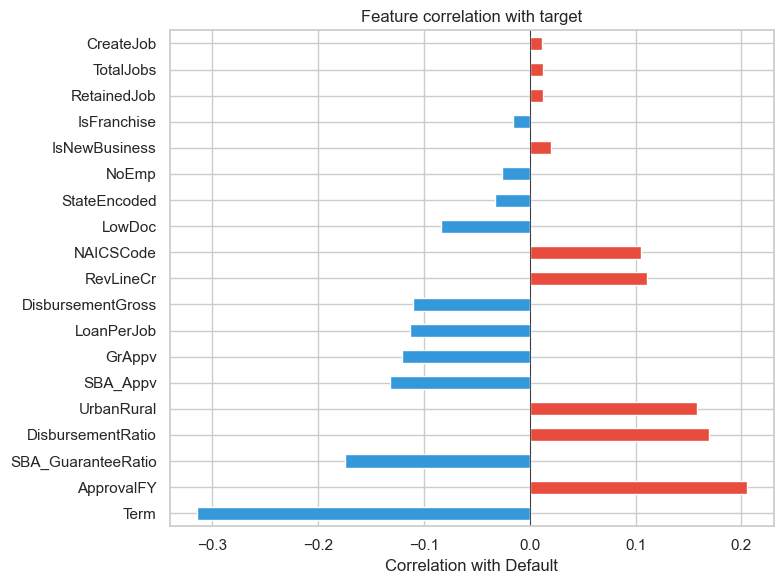


Top positive correlators (increase default risk):
ApprovalFY           0.204902
DisbursementRatio    0.169439
UrbanRural           0.158483
RevLineCr            0.110728
NAICSCode            0.105166
dtype: float64

Top negative correlators (decrease default risk):
Term                 -0.314121
SBA_GuaranteeRatio   -0.174810
SBA_Appv             -0.132232
GrAppv               -0.120424
LoanPerJob           -0.112917
dtype: float64


In [11]:
correlations = X.corrwith(y).sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 6))
correlations.plot(kind='barh', color=['#e74c3c' if v > 0 else '#3498db' for v in correlations])
plt.xlabel('Correlation with Default')
plt.title('Feature correlation with target')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('\nTop positive correlators (increase default risk):')
print(correlations[correlations > 0].head())
print('\nTop negative correlators (decrease default risk):')
print(correlations[correlations < 0].head())

## 11. Persist processed data

In [12]:
X.to_csv('../data/X_processed.csv', index=False)
y.to_csv('../data/y_processed.csv', index=False)

with open('../models/feature_names.json', 'w') as f:
    json.dump(FEATURES, f)

print('Wrote:')
print('  ../data/X_processed.csv')
print('  ../data/y_processed.csv')
print('  ../models/feature_names.json')

Wrote:
  ../data/X_processed.csv
  ../data/y_processed.csv
  ../models/feature_names.json
